# Unidad 3 · Estocástico MULTIETAPA: un árbol y el valor de poder adaptarse

**Planta:** Conservas del Itata S.A. — programa de envases retornables
**Datos:** `DatosClases/3_Planificacion/Remanufactura/` — el flujo circular del cuaderno 08, más `itata_reman_arbol.csv`
**Solver:** Gurobi

---

## Qué se decide aquí

En el cuaderno 07 la incertidumbre se revelaba **de golpe**: se decidía la
primera etapa, se observaba la demanda completa de las doce semanas y se
corregía una vez. Es una buena aproximación cuando hay un único momento de
compromiso, y una mala cuando la información llega de a poco —que es el caso
de cualquier plan que se rehace cada mes.

En el programa de envases retornables la información llega **por etapas**. Al
final del primer cuatrimestre la planta ya sabe si el programa está siendo
bien recibido —vuelven más envases— o no; al final del segundo sabe otra cosa.
Y el plan del tercer cuatrimestre puede aprovechar todo lo observado hasta
entonces. El objeto que representa eso es un **árbol de escenarios**:

* cada **nodo** es un estado de información —lo que se sabe en ese momento—;
* los **hijos** de un nodo son las continuaciones posibles desde ahí;
* la **probabilidad** de un nodo es la del camino que lleva hasta él.

Aquí: 7 nodos, 3 etapas de 4 semanas cada una, 4 trayectorias completas.

## La no anticipatividad, gratis

Esta es la idea central del cuaderno, y es una idea de **indexación**, no de
restricciones. Si se escribe **una variable por NODO** en vez de una por
escenario y período, la no anticipatividad sale **automática**: dos
trayectorias que todavía no se distinguen pasan por el mismo nodo y
comparten, por construcción, la misma decisión. No hay que escribir ni una
restricción para imponerla, y no hay forma de olvidarse de escribirla.

La alternativa —una variable por escenario, más restricciones explícitas del
tipo $x_{s_1 t} = x_{s_2 t}$ para todo par de escenarios indistinguibles hasta
$t$— da el mismo óptimo con muchas más variables, muchas más restricciones y
una oportunidad de equivocarse en cada par.

## El estado cruza la rama

Lo que sí hay que escribir con cuidado es el **enlace entre un nodo y su
padre**. El inventario que entra al primer período de un nodo es el que sale
del último período de su padre. Y —esto es más fácil de equivocar— las partes
que llegan en $(n,t)$ salieron de un desensamble hecho $L$ períodos antes, que
**puede haber ocurrido en un nodo ANCESTRO**. Por eso el modelo recorre el
camino desde la raíz, no la lista de períodos del nodo.

## Cifras de referencia

| plan | costo esperado (CLP) |
|---|---|
| multietapa, adaptativo | **107 973 125** |
| mismo árbol, plan rígido (una decisión por etapa) | **114 313 712** |
| **valor de la adaptación** | **6 340 587 (5,55 %)** |

## Dos cosas que este cuaderno no omite

**1. El contrafactual correcto NO es el problema con demanda promedio.** Por
la desigualdad de Jensen, ese problema puede costar **menos** que el
estocástico, y entonces el "valor de la adaptación" sale negativo y no
significa nada. La sección 6 lo resuelve y muestra el número negativo. El
contrafactual con signo garantizado es el **mismo árbol con una restricción
extra**: todos los nodos de una misma etapa deben tomar la misma decisión. Al
ser una restricción del multietapa, su costo es necesariamente mayor o igual.

**2. Un árbol con dos raíces no es un árbol.** Si la primera etapa tiene más
de un nodo, la decisión de hoy ya depende de información que todavía no se
observa —que es exactamente lo que el modelo multietapa existe para prohibir—.
El solver lo aceptaría sin quejarse y devolvería un costo **más bajo**. Lo que
está mal no es el modelo: es el dato. La sección 7 lo construye a propósito.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

hor = pd.read_csv(datos("3_Remanufactura", "itata_reman_horizonte.csv"))
par = pd.read_csv(datos("3_Remanufactura", "itata_reman_parametros.csv")).iloc[0]
proc = pd.read_csv(datos("3_Remanufactura", "itata_reman_procesos.csv")).set_index("proceso")
arbol_df = pd.read_csv(datos("3_Remanufactura", "itata_reman_arbol.csv"))

T = hor.t.astype(int).tolist()
retornos = dict(zip(T, hor.retornos.astype(float)))
rendimiento = dict(zip(T, hor.rendimiento.astype(float)))
horas = dict(zip(T, hor.horas_disponibles.astype(float)))
horas_extra_max = dict(zip(T, hor.horas_extra_max.astype(float)))
costo_hora_extra = dict(zip(T, hor.costo_hora_extra_clp.astype(float)))
demanda_base = dict(zip(T, hor.demanda.astype(float)))

C_ACEPTAR = float(par.costo_aceptar)
C_DESENS = float(par.costo_desensamble)
C_RECUP = float(par.costo_recuperacion)
C_REENS = float(par.costo_reensamble)
C_NUEVO = float(par.costo_nuevo)
PENAL_PERDIDA = float(par.penal_venta_perdida)
SETUP_A = float(par.setup_reensamble)
ALMACEN = {"C": float(par.almacen_core), "P": float(par.almacen_parte),
           "S": float(par.almacen_producto)}
T_UNIT = {k: float(proc.loc[k, "horas_por_unidad"]) for k in ("D", "R", "A")}
T_SETUP = {k: float(proc.loc[k, "horas_setup"]) for k in ("D", "R", "A")}
L = int(par.lead_desensamble)
INV0 = {"C": float(par.inv_inicial_core), "P": float(par.inv_inicial_parte),
        "S": float(par.inv_inicial_producto)}

print(arbol_df.to_string(index=False))

 nodo  padre  etapa  probabilidad  t  demanda  mult_retornos
    1      0      1          1.00  1   2400.0         1.0000
    1      0      1          1.00  2   2664.0         1.0000
    1      0      1          1.00  3   2857.0         1.0000
    1      0      1          1.00  4   2928.0         1.0000
    2      1      2          0.50  5   2514.0         1.1000
    2      1      2          0.50  6   2344.0         1.1000
    2      1      2          0.50  7   2112.0         1.1000
    2      1      2          0.50  8   1880.0         1.1000
    3      1      2          0.50  5   3257.0         0.8600
    3      1      2          0.50  6   3037.0         0.8600
    3      1      2          0.50  7   2736.0         0.8600
    3      1      2          0.50  8   2435.0         0.8600
    4      2      3          0.25  9   1505.0         1.2100
    4      2      3          0.25 10   1450.0         1.2100
    4      2      3          0.25 11   1505.0         1.2100
    4      2      3     

## 1. El árbol, y la validación que hay que hacer antes de modelar

La tabla trae una fila por `(nodo, período)` con el nodo padre, la etapa, la
probabilidad del nodo, la demanda y un multiplicador de retornos. Antes de
escribir una sola restricción hay que comprobar tres cosas, porque el modelo
**no** las comprueba:

1. **La raíz es única.** Debe haber exactamente un nodo en la primera etapa.
   Si hay dos, la decisión de hoy depende de algo que todavía no se observa.
2. **Las probabilidades de las hojas suman uno.** Son las trayectorias
   completas; si no suman uno, el costo esperado está escalado por un factor
   arbitrario y no es comparable con nada.
3. **Cada nodo salvo la raíz tiene un padre que existe**, y los períodos de
   los nodos, concatenados a lo largo de cualquier camino raíz-hoja, cubren el
   horizonte completo sin huecos ni repeticiones.

Ninguna de las tres produce un error del solver si falla.

In [2]:
class Arbol:
    """Árbol de escenarios leído de la tabla (nodo, padre, etapa, prob, t, ...).

    Se indexa una sola vez al construirlo: los métodos son consultas a
    diccionarios, no filtros sobre el DataFrame.
    """

    def __init__(self, tb: pd.DataFrame):
        self.tabla = tb
        self.padre, self.etapa, self.prob, self.per = {}, {}, {}, {}
        for n, g in tb.groupby("nodo"):
            n = int(n)
            self.padre[n] = int(g.padre.iloc[0])
            self.etapa[n] = int(g.etapa.iloc[0])
            self.prob[n] = float(g.probabilidad.iloc[0])
            self.per[n] = sorted(int(v) for v in g.t)
        self.dem = {(int(r.nodo), int(r.t)): float(r.demanda)
                    for r in tb.itertuples()}
        self.mult = {(int(r.nodo), int(r.t)): float(r.mult_retornos)
                     for r in tb.itertuples()}
        self.nodos = sorted(self.padre)

    def etapas(self):
        return sorted(set(self.etapa.values()))

    def nodos_de_etapa(self, e):
        return [n for n in self.nodos if self.etapa[n] == e]

    def raices(self):
        return self.nodos_de_etapa(min(self.etapa.values()))

    def hojas(self):
        return self.nodos_de_etapa(max(self.etapa.values()))

    def hijos(self, n):
        return [m for m in self.nodos if self.padre[m] == n and m != n]

    def camino(self, n):
        """Nodos desde la raíz hasta n, en orden."""
        out, cur, visto = [], int(n), set()
        while cur in self.padre and cur not in visto:
            visto.add(cur)
            out.append(cur)
            cur = self.padre[cur]
        return list(reversed(out))

    def ruta(self, n):
        """Pares (nodo, t) desde la raíz hasta el final de n, en orden."""
        out = []
        for m in self.camino(n):
            out.extend((m, t) for t in self.per[m])
        return out


A = Arbol(arbol_df)
print(f"nodos      : {len(A.nodos)}  {A.nodos}")
print(f"etapas     : {A.etapas()}")
print(f"raíces     : {A.raices()}")
print(f"hojas      : {A.hojas()}")
print(f"suma de probabilidades en las hojas: {sum(A.prob[h] for h in A.hojas()):.6f}")
print()
for n in A.nodos:
    print(f"  nodo {n}  padre {A.padre[n]}  etapa {A.etapa[n]}  "
          f"p = {A.prob[n]:.2f}  semanas {A.per[n]}  "
          f"demanda media {np.mean([A.dem[(n,t)] for t in A.per[n]]):7,.0f}  "
          f"mult. retornos {A.mult[(n, A.per[n][0])]:.4f}")

assert len(A.raices()) == 1, "un árbol con más de una raíz no es un árbol"
assert abs(sum(A.prob[h] for h in A.hojas()) - 1.0) < 1e-9
for h in A.hojas():
    ts = [t for _, t in A.ruta(h)]
    assert ts == sorted(T), f"la trayectoria de la hoja {h} no cubre el horizonte"
print("\nLas tres validaciones pasan: raíz única, probabilidades que suman uno,")
print("y trayectorias que cubren las doce semanas sin huecos ni repeticiones.")

nodos      : 7  [1, 2, 3, 4, 5, 6, 7]
etapas     : [1, 2, 3]
raíces     : [1]
hojas      : [4, 5, 6, 7]
suma de probabilidades en las hojas: 1.000000

  nodo 1  padre 0  etapa 1  p = 1.00  semanas [1, 2, 3, 4]  demanda media   2,712  mult. retornos 1.0000
  nodo 2  padre 1  etapa 2  p = 0.50  semanas [5, 6, 7, 8]  demanda media   2,212  mult. retornos 1.1000
  nodo 3  padre 1  etapa 2  p = 0.50  semanas [5, 6, 7, 8]  demanda media   2,866  mult. retornos 0.8600
  nodo 4  padre 2  etapa 3  p = 0.25  semanas [9, 10, 11, 12]  demanda media   1,528  mult. retornos 1.2100
  nodo 5  padre 2  etapa 3  p = 0.25  semanas [9, 10, 11, 12]  demanda media   1,980  mult. retornos 0.9460
  nodo 6  padre 3  etapa 3  p = 0.25  semanas [9, 10, 11, 12]  demanda media   1,980  mult. retornos 0.9460
  nodo 7  padre 3  etapa 3  p = 0.25  semanas [9, 10, 11, 12]  demanda media   2,565  mult. retornos 0.7396

Las tres validaciones pasan: raíz única, probabilidades que suman uno,
y trayectorias que cubren las 

## 2. El modelo, indexado por nodo

El modelo físico es el del cuaderno 08 —tres inventarios acoplados, el
rendimiento multiplicando el desensamble de hace $L$ períodos, venta perdida
penalizada— con dos cambios:

* **todas las variables se indexan por $(n, t)$** en vez de por $t$;
* **el único binario que se conserva es el setup del reensamble** $y^A_{nt}$.
  Con setups en los tres procesos el árbol seguiría cabiendo, pero el foco del
  cuaderno es la estructura multietapa y no la combinatoria de las
  preparaciones, que ya se trabajó en el 08.

El objetivo pondera el costo de cada nodo por **su** probabilidad:

$$\min \sum_{n} p_n \sum_{t \in T_n} \big[\text{costo del período } (n,t)\big]$$

Los nodos intermedios pesan por la suya, que es la suma de la de sus
descendientes; por eso la raíz pesa 1 y cada hoja 0,25.

### Las dos funciones que hacen el trabajo

**`estado_previo(n, t, var)`** devuelve el inventario que entra a $(n,t)$: el
del período anterior del **mismo** nodo si $t$ no es el primero, y el del
**último período del padre** si lo es. Es el enlace que transmite el estado a
través del árbol.

**`anterior_L`** es un diccionario que, para cada par $(n,t)$, guarda el par
$(n', t')$ que está $L$ períodos antes **a lo largo del camino desde la
raíz**. Cuando $t$ es el primer período de un nodo, ese par pertenece al
padre. Construirlo recorriendo `ruta(hoja)` para cada hoja es la forma directa
de no equivocarse: dos hojas que comparten un tramo escriben el mismo valor.

In [3]:
def construir(A, rigido=False, tiempo_limite=240.0, gap=1e-4, lead_time=True):
    """Modelo multietapa de flujo circular sobre el árbol A."""
    LL = L if lead_time else 0
    pares = [(n, t) for n in A.nodos for t in A.per[n]]

    # (n,t) -> el par que esta L periodos antes en el camino desde la raiz.
    # Puede pertenecer a un nodo ANCESTRO: por eso se recorre la ruta completa.
    anterior_L = {}
    for h in A.hojas():
        r = A.ruta(h)
        for i, par in enumerate(r):
            anterior_L[par] = r[i - LL] if (LL > 0 and i - LL >= 0) else (
                par if LL == 0 else None)

    m = gp.Model("MULTIETAPA")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    a = m.addVars(pares, lb=0.0, name="aceptar")
    u = m.addVars(pares, lb=0.0, name="desensamblar")
    v = m.addVars(pares, lb=0.0, name="recuperar")
    x = m.addVars(pares, lb=0.0, name="reensamblar")
    mm = m.addVars(pares, lb=0.0, name="nuevo")
    C = m.addVars(pares, lb=0.0, name="invCore")
    P = m.addVars(pares, lb=0.0, name="invParte")
    S = m.addVars(pares, lb=0.0, name="invProducto")
    o = m.addVars(pares, lb=0.0, name="horasExtra")
    l = m.addVars(pares, lb=0.0, name="perdida")
    yA = m.addVars(pares, vtype=GRB.BINARY, name="yA")

    M_prod = sum(A.dem.values()) / max(1, len(A.hojas())) + INV0["S"]
    M_prod = sum(demanda_base.values()) + INV0["S"]

    def estado_previo(n, t, var, inicial):
        """El inventario que entra a (n,t): período anterior del mismo nodo, o
        último período del nodo PADRE si t es el primero del nodo."""
        per = A.per[n]
        k = per.index(t)
        if k > 0:
            return var[n, per[k - 1]]
        p = A.padre[n]
        if p in A.padre:                       # el padre existe: cruza la rama
            return var[p, A.per[p][-1]]
        return inicial                          # es la raíz: inventario inicial

    for (n, t) in pares:
        dem = A.dem[(n, t)]
        ret = retornos[t] * A.mult[(n, t)]

        m.addConstr(estado_previo(n, t, C, INV0["C"]) + a[n, t] - u[n, t]
                    == C[n, t], name=f"balC[{n},{t}]")

        prev = anterior_L.get((n, t))
        if prev is None:
            llega = 0.0
        else:
            np_, tp_ = prev
            llega = rendimiento[tp_] * u[np_, tp_]
        m.addConstr(estado_previo(n, t, P, INV0["P"]) + llega - v[n, t]
                    == P[n, t], name=f"balP[{n},{t}]")

        m.addConstr(estado_previo(n, t, S, INV0["S"]) + x[n, t] + mm[n, t]
                    - dem + l[n, t] == S[n, t], name=f"balS[{n},{t}]")

        m.addConstr(x[n, t] <= v[n, t], name=f"reensamble_acotado[{n},{t}]")
        m.addConstr(a[n, t] <= ret, name=f"oferta[{n},{t}]")
        m.addConstr(x[n, t] <= M_prod * yA[n, t], name=f"enlA[{n},{t}]")

        carga = (T_UNIT["D"] * u[n, t] + T_UNIT["R"] * v[n, t]
                 + T_UNIT["A"] * x[n, t] + T_SETUP["A"] * yA[n, t])
        m.addConstr(carga <= horas[t] + o[n, t], name=f"cap[{n},{t}]")
        m.addConstr(o[n, t] <= horas_extra_max[t], name=f"topeExtra[{n},{t}]")

    # --- plan RIGIDO: todos los nodos de una etapa deciden lo mismo.
    #     Es una RESTRICCION del multietapa, luego su costo es >=.
    n_rigidas = 0
    if rigido:
        for e in A.etapas():
            ns = A.nodos_de_etapa(e)
            if len(ns) < 2:
                continue
            ref = ns[0]
            for n in ns[1:]:
                for k, t in enumerate(A.per[n]):
                    tr = A.per[ref][k]
                    for var in (a, u, v, x, mm, yA):
                        m.addConstr(var[n, t] == var[ref, tr],
                                    name=f"rigido[{n},{t}]")
                        n_rigidas += 1

    costo = gp.quicksum(
        A.prob[n] * (C_ACEPTAR * a[n, t] + C_DESENS * u[n, t]
                     + C_RECUP * v[n, t] + C_REENS * x[n, t] + C_NUEVO * mm[n, t]
                     + SETUP_A * yA[n, t]
                     + ALMACEN["C"] * C[n, t] + ALMACEN["P"] * P[n, t]
                     + ALMACEN["S"] * S[n, t]
                     + costo_hora_extra[t] * o[n, t] + PENAL_PERDIDA * l[n, t])
        for (n, t) in pares)
    m.setObjective(costo, GRB.MINIMIZE)

    var = {"a": a, "u": u, "v": v, "x": x, "m": mm, "C": C, "P": P, "S": S,
           "o": o, "l": l, "yA": yA}
    return m, var, n_rigidas


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def resolver(etiqueta, A, **kw):
    t0 = time.perf_counter()
    m, var, nr = construir(A, **kw)
    m.optimize()
    seg = time.perf_counter() - t0
    print(f"{etiqueta:34s} {ESTADO.get(m.Status, m.Status):8s} "
          f"obj {m.ObjVal:>14,.0f} | gap {100*m.MIPGap:4.2f} % | "
          f"{m.NumVars} var ({m.NumBinVars} bin), {m.NumConstrs} restr"
          + (f" ({nr} de rigidez)" if nr else "") + f" | {seg:4.1f} s")
    return m, var, seg

## 3. El plan adaptativo y el plan rígido

El primero es el multietapa: cada nodo decide lo suyo, sabiendo lo que se
observó hasta llegar ahí. El segundo es el **mismo árbol** con la restricción
de que todos los nodos de una etapa tomen la misma decisión: un plan que se
fija de antemano para las tres etapas y se ejecuta pase lo que pase.

La comparación tiene signo garantizado porque el segundo conjunto factible
está **contenido** en el primero. Esa es toda la gracia del contrafactual, y
es lo que la sección 6 muestra que el promedio no tiene.

In [4]:
m_adap, v_adap, _ = resolver("multietapa (adaptativo)", A)
m_rig, v_rig, _ = resolver("mismo árbol, plan rígido", A, rigido=True)

Z_ADAP, Z_RIG = m_adap.ObjVal, m_rig.ObjVal
VALOR = Z_RIG - Z_ADAP
print(f"\nvalor de la adaptación = {Z_RIG:,.0f} - {Z_ADAP:,.0f} = "
      f"{VALOR:,.0f} CLP  ({100*VALOR/Z_RIG:.2f} % del plan rígido)")

Restricted license - for non-production use only - expires 2027-11-29


multietapa (adaptativo)            OPTIMAL  obj    107,973,125 | gap 0.00 % | 308 var (28 bin), 224 restr |  0.1 s
mismo árbol, plan rígido           OPTIMAL  obj    114,313,712 | gap 0.00 % | 308 var (28 bin), 320 restr (96 de rigidez) |  0.0 s

valor de la adaptación = 114,313,712 - 107,973,125 = 6,340,587 CLP  (5.55 % del plan rígido)


## 4. Dónde está la adaptación, nodo por nodo

El número de arriba es un promedio. Lo que hay que mirar para entenderlo es
**qué hace distinto** el plan adaptativo en dos nodos hermanos, es decir, en
dos futuros que se distinguen justo ahí.

In [5]:
filas = []
for n in A.nodos:
    per = A.per[n]
    filas.append({
        "nodo": n, "padre": A.padre[n], "etapa": A.etapa[n], "p": A.prob[n],
        "semanas": f"{per[0]}-{per[-1]}",
        "demanda": sum(A.dem[(n, t)] for t in per),
        "mult_ret": A.mult[(n, per[0])],
        "aceptados": sum(v_adap["a"][n, t].X for t in per),
        "desensambla": sum(v_adap["u"][n, t].X for t in per),
        "reensambla": sum(v_adap["x"][n, t].X for t in per),
        "nuevos": sum(v_adap["m"][n, t].X for t in per),
        "perdida": sum(v_adap["l"][n, t].X for t in per),
        "rigido_reensambla": sum(v_rig["x"][n, t].X for t in per),
        "rigido_nuevos": sum(v_rig["m"][n, t].X for t in per)})
nodos = pd.DataFrame(filas)
nodos["circularidad_%"] = 100 * nodos.reensambla / (nodos.reensambla + nodos.nuevos)
print(nodos.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

print("\nLos nodos 2 y 3 son la MISMA decisión vista desde dos futuros distintos:")
print("el 2 con retornos altos (x1,10) y demanda baja, el 3 al revés (x0,86).")
print("En el plan adaptativo cada uno hace lo suyo; en el rígido tienen que")
print("hacer lo mismo, y el costo de esa igualdad es el valor de la adaptación.")

hermanos = pd.DataFrame({
    "nodo 2 (retornos altos)": nodos[nodos.nodo == 2].iloc[0],
    "nodo 3 (retornos bajos)": nodos[nodos.nodo == 3].iloc[0]}).loc[
    ["demanda", "mult_ret", "aceptados", "reensambla", "nuevos",
     "rigido_reensambla", "rigido_nuevos"]]
print()
print(hermanos.to_string(float_format=lambda v: f"{v:,.1f}"))

 nodo  padre  etapa   p semanas  demanda  mult_ret  aceptados  desensambla  reensambla  nuevos  perdida  rigido_reensambla  rigido_nuevos  circularidad_%
    1      0      1 1.0     1-4 10,849.0       1.0    1,914.6      2,781.4     2,474.1 7,754.9      0.0            2,474.1        7,754.9            24.2
    2      1      2 0.5     5-8  8,850.0       1.1    7,681.9      7,715.0     2,474.1 6,375.9      0.0            2,474.1        6,375.9            28.0
    3      1      2 0.5     5-8 11,465.0       0.9    5,730.3      5,763.5     2,474.1 8,990.9      0.0            2,474.1        6,375.9            21.6
    4      2      3 0.2    9-12  6,114.0       1.2      817.6        817.6     4,948.3 1,165.7      0.0            6,960.3          958.7            80.9
    5      2      3 0.2    9-12  7,919.0       0.9    3,032.2      3,032.2     6,879.5 1,039.5      0.0            6,960.3          958.7            86.9
    6      3      3 0.2    9-12  7,919.0       0.9    2,430.9      2,430.9  

## 5. El estado sí cruza la rama: la comprobación

Antes de seguir conviene verificar que el enlace entre nodos funciona, porque
es la parte que un modelo mal escrito silencia. Se recalculan los tres
balances **desde la solución**, usando el padre para el primer período de cada
nodo y el ancestro correcto para el lead time del desensamble. Si el modelo
hubiera usado el inventario del propio nodo en el primer período —el error
habitual—, el residuo no daría cero.

In [6]:
LL = L
anterior_L = {}
for h in A.hojas():
    r = A.ruta(h)
    for i, par in enumerate(r):
        anterior_L[par] = r[i - LL] if i - LL >= 0 else None


def previo(n, t, clave, inicial, V):
    per = A.per[n]
    k = per.index(t)
    if k > 0:
        return V[clave][n, per[k - 1]].X
    p = A.padre[n]
    if p in A.padre:
        return V[clave][p, A.per[p][-1]].X
    return inicial


peorC = peorP = peorS = 0.0
cruces = 0
for n in A.nodos:
    for t in A.per[n]:
        pc = previo(n, t, "C", INV0["C"], v_adap)
        pp = previo(n, t, "P", INV0["P"], v_adap)
        ps = previo(n, t, "S", INV0["S"], v_adap)
        pr = anterior_L.get((n, t))
        llega = 0.0
        if pr is not None:
            np_, tp_ = pr
            llega = rendimiento[tp_] * v_adap["u"][np_, tp_].X
            if np_ != n:
                cruces += 1
        peorC = max(peorC, abs(pc + v_adap["a"][n, t].X - v_adap["u"][n, t].X
                               - v_adap["C"][n, t].X))
        peorP = max(peorP, abs(pp + llega - v_adap["v"][n, t].X
                               - v_adap["P"][n, t].X))
        peorS = max(peorS, abs(ps + v_adap["x"][n, t].X + v_adap["m"][n, t].X
                               - A.dem[(n, t)] + v_adap["l"][n, t].X
                               - v_adap["S"][n, t].X))

print(f"residuo máximo, balance de cores   : {peorC:.3e}")
print(f"residuo máximo, balance de partes  : {peorP:.3e}")
print(f"residuo máximo, balance de producto: {peorS:.3e}")
print(f"\npares (nodo, período) cuyo desensamble de hace L períodos ocurrió en un")
print(f"nodo ANCESTRO: {cruces}. Son los primeros períodos de los nodos 2 a 7, y")
print("son exactamente los que un modelo escrito 'por período dentro del nodo'")
print("habría dejado sin material sin que nadie lo notara.")

residuo máximo, balance de cores   : 0.000e+00
residuo máximo, balance de partes  : 9.095e-13
residuo máximo, balance de producto: 1.137e-13

pares (nodo, período) cuyo desensamble de hace L períodos ocurrió en un
nodo ANCESTRO: 6. Son los primeros períodos de los nodos 2 a 7, y
son exactamente los que un modelo escrito 'por período dentro del nodo'
habría dejado sin material sin que nadie lo notara.


## 6. El contrafactual equivocado: la demanda promedio y Jensen

La comparación que casi todo el mundo hace es contra el problema
determinístico con la **demanda promedio**. Suena razonable y está mal, y la
razón es la desigualdad de Jensen: el valor óptimo de un problema de
minimización es una función **cóncava** de los datos del lado derecho, de modo
que

$$z(\mathbb{E}[d]) \;\le\; \mathbb{E}[z(d)]$$

El problema promediado puede costar **menos** que el estocástico, porque
resolver sobre un dato promedio no es lo mismo que promediar las soluciones:
los picos y los valles se cancelan en el dato y no se cancelan en la planta.

Se construye un árbol degenerado —**un solo nodo** con las doce semanas y la
demanda esperada de cada una— y se resuelve con exactamente el mismo código.

In [7]:
filas = []
for t in T:
    ns = [n for n in A.nodos if t in A.per[n]]
    filas.append({"nodo": 1, "padre": 0, "etapa": 1, "probabilidad": 1.0, "t": t,
                  "demanda": sum(A.prob[n] * A.dem[(n, t)] for n in ns),
                  "mult_retornos": sum(A.prob[n] * A.mult[(n, t)] for n in ns)})
A_prom = Arbol(pd.DataFrame(filas))
m_prom, v_prom, _ = resolver("demanda promedio (1 nodo)", A_prom)
Z_PROM = m_prom.ObjVal

print()
print(f"  multietapa                       : {Z_ADAP:>14,.0f} CLP")
print(f"  plan rígido sobre el mismo árbol : {Z_RIG:>14,.0f} CLP  "
      f"-> valor de la adaptación {VALOR:>+12,.0f}")
print(f"  determinístico con demanda media : {Z_PROM:>14,.0f} CLP  "
      f"-> 'valor' contra el promedio {Z_PROM - Z_ADAP:>+12,.0f}")
print("\nEl segundo número es NEGATIVO: el problema promediado cuesta MENOS que el")
print("estocástico. Presentado como 'valor de la adaptación' diría que adaptarse")
print("destruye valor, que es un sinsentido. No hay ningún error de cálculo: es")
print("Jensen. El promedio no es un plan alternativo, es OTRO problema, y por eso")
print("no sirve de contrafactual.")
print("\nEl plan rígido, en cambio, es un plan de verdad: se puede ejecutar, se")
print("evalúa sobre los MISMOS escenarios, y su conjunto factible está contenido")
print("en el del multietapa. Por eso su diferencia tiene signo garantizado.")

demanda promedio (1 nodo)          OPTIMAL  obj    107,893,757 | gap 0.00 % | 132 var (12 bin), 96 restr |  0.0 s

  multietapa                       :    107,973,125 CLP
  plan rígido sobre el mismo árbol :    114,313,712 CLP  -> valor de la adaptación   +6,340,587
  determinístico con demanda media :    107,893,757 CLP  -> 'valor' contra el promedio      -79,368

El segundo número es NEGATIVO: el problema promediado cuesta MENOS que el
estocástico. Presentado como 'valor de la adaptación' diría que adaptarse
destruye valor, que es un sinsentido. No hay ningún error de cálculo: es
Jensen. El promedio no es un plan alternativo, es OTRO problema, y por eso
no sirve de contrafactual.

El plan rígido, en cambio, es un plan de verdad: se puede ejecutar, se
evalúa sobre los MISMOS escenarios, y su conjunto factible está contenido
en el del multietapa. Por eso su diferencia tiene signo garantizado.


## 7. Un árbol con dos raíces no es un árbol

El último error del cuaderno es de **datos**, no de modelo. Se construye a
propósito un árbol en que la primera etapa tiene dos nodos —uno que lleva al
futuro de retornos altos y otro al de retornos bajos— con las mismas doce
semanas y los mismos datos de la primera etapa.

Visto como tabla parece inofensivo: las probabilidades siguen sumando uno,
cada nodo tiene padre, los períodos cubren el horizonte. Y el modelo lo
resuelve sin decir nada.

Lo que pasa es que ahora **la decisión de la semana 1 puede depender de cuál
de los dos futuros va a ocurrir**, información que en la semana 1 nadie tiene.
El modelo no lo sabe: para él son dos nodos raíz y cada uno optimiza lo suyo.
El síntoma es un costo **menor** —siempre menor, porque se relajó la no
anticipatividad— y dos planes distintos para el mismo "hoy".

In [8]:
malas = []
for r in arbol_df.itertuples():
    n = int(r.nodo)
    if n == 1:
        for nuevo, pp in ((101, 0.5), (102, 0.5)):
            malas.append({"nodo": nuevo, "padre": 0, "etapa": 1,
                          "probabilidad": pp, "t": int(r.t),
                          "demanda": r.demanda, "mult_retornos": r.mult_retornos})
    else:
        pa = int(r.padre)
        pa = 101 if (pa == 1 and n == 2) else (102 if (pa == 1 and n == 3) else pa)
        malas.append({"nodo": n, "padre": pa, "etapa": int(r.etapa),
                      "probabilidad": float(r.probabilidad), "t": int(r.t),
                      "demanda": r.demanda, "mult_retornos": r.mult_retornos})
A_mal = Arbol(pd.DataFrame(malas))

print(f"raíces del árbol mal formado: {A_mal.raices()}  "
      f"(deberían ser exactamente una)")
print(f"probabilidades de las hojas : suma "
      f"{sum(A_mal.prob[h] for h in A_mal.hojas()):.4f}  (sigue cuadrando)")
m_mal, v_mal, _ = resolver("árbol con DOS raíces", A_mal)

print(f"\n  multietapa con raíz única : {Z_ADAP:>14,.0f} CLP")
print(f"  'multietapa' con dos raíces: {m_mal.ObjVal:>14,.0f} CLP  "
      f"({m_mal.ObjVal - Z_ADAP:+,.0f})")

print("\nLa decisión de la PRIMERA etapa, que debería ser una sola, sale doble:")
cmp_raiz = pd.DataFrame({
    "semana": A_mal.per[101],
    "raíz 101 (va al futuro alto)": [v_mal["a"][101, t].X for t in A_mal.per[101]],
    "raíz 102 (va al futuro bajo)": [v_mal["a"][102, t].X for t in A_mal.per[102]],
    "raíz única (correcto)": [v_adap["a"][1, t].X for t in A.per[1]]})
print(cmp_raiz.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
dif_raiz = max(abs(v_mal["a"][101, t].X - v_mal["a"][102, t].X)
               for t in A_mal.per[101])
print(f"\nmáxima diferencia entre las dos 'primeras etapas': {dif_raiz:,.1f} cores")
print("\nSi ese número no es cero, el plan pide aceptar hoy una cantidad distinta")
print("según lo que pase dentro de cuatro meses. Es inejecutable, y el solver no")
print("tiene forma de saberlo: lo que está mal es el dato, no el modelo. Por eso")
print("la validación de la sección 1 es parte del modelo, no un adorno.")

raíces del árbol mal formado: [101, 102]  (deberían ser exactamente una)
probabilidades de las hojas : suma 1.0000  (sigue cuadrando)


árbol con DOS raíces               OPTIMAL  obj    107,953,334 | gap 0.00 % | 352 var (32 bin), 256 restr |  0.1 s

  multietapa con raíz única :    107,973,125 CLP
  'multietapa' con dos raíces:    107,953,334 CLP  (-19,791)

La decisión de la PRIMERA etapa, que debería ser una sola, sale doble:
 semana  raíz 101 (va al futuro alto)  raíz 102 (va al futuro bajo)  raíz única (correcto)
      1                         680.4                         680.4                  680.4
      2                       1,201.0                       1,201.0                1,201.0
      3                       1,405.4                           0.7                    0.0
      4                       1,809.0                       1,809.0                   33.2

máxima diferencia entre las dos 'primeras etapas': 1,404.7 cores

Si ese número no es cero, el plan pide aceptar hoy una cantidad distinta
según lo que pase dentro de cuatro meses. Es inejecutable, y el solver no
tiene forma de saberlo: lo que es

## 8. El gráfico: el árbol, dibujado

A la izquierda, el árbol con lo que lo define: probabilidad, demanda del
tramo y multiplicador de retornos. A la derecha, lo que el plan **adaptativo**
decide en cada nodo, comparado con lo que el plan **rígido** está obligado a
decidir en los nodos de la misma etapa. Donde las dos barras se separan, ahí
está el valor de la adaptación.

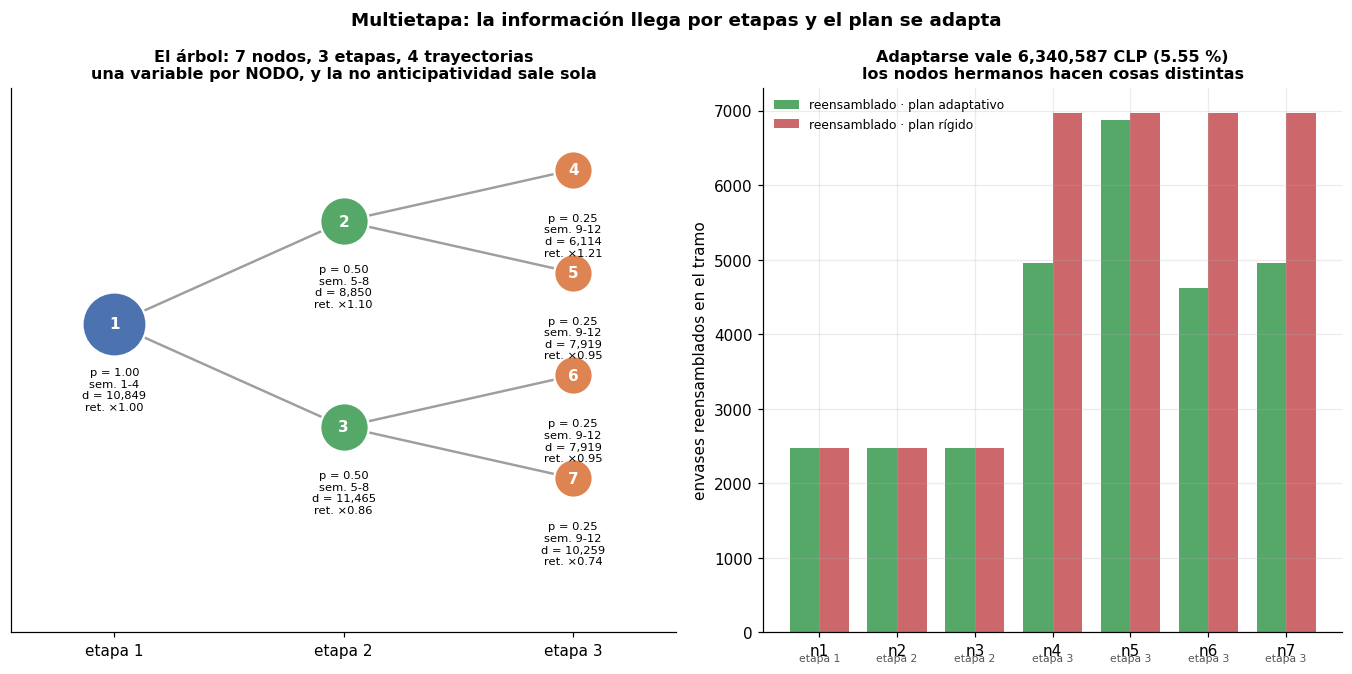

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 6.2),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# --- disposicion del arbol: hojas equiespaciadas, padres en el centro de sus hijos
ypos, hojas = {}, A.hojas()
for k, h in enumerate(hojas):
    ypos[h] = len(hojas) - 1 - k
for e in sorted(A.etapas(), reverse=True):
    for n in A.nodos_de_etapa(e):
        if n in ypos:
            continue
        hijos = A.hijos(n)
        ypos[n] = float(np.mean([ypos[c] for c in hijos])) if hijos else 0.0

col_etapa = {1: "#4c72b0", 2: "#55a868", 3: "#dd8452"}
for n in A.nodos:
    p = A.padre[n]
    if p in A.padre:
        ax1.plot([A.etapa[p], A.etapa[n]], [ypos[p], ypos[n]],
                 color="#9e9e9e", lw=1.6, zorder=1)
for n in A.nodos:
    ax1.scatter([A.etapa[n]], [ypos[n]], s=1500 * A.prob[n] + 260,
                color=col_etapa[A.etapa[n]], zorder=2, edgecolor="white", lw=1.5)
    ax1.text(A.etapa[n], ypos[n], str(n), ha="center", va="center",
             color="white", fontweight="bold", fontsize=10, zorder=3)
    per = A.per[n]
    ax1.text(A.etapa[n], ypos[n] - 0.42,
             f"p = {A.prob[n]:.2f}\nsem. {per[0]}-{per[-1]}\n"
             f"d = {sum(A.dem[(n,t)] for t in per):,.0f}\n"
             f"ret. ×{A.mult[(n, per[0])]:.2f}",
             ha="center", va="top", fontsize=7.5)
ax1.set_xticks(sorted(A.etapas()))
ax1.set_xticklabels([f"etapa {e}" for e in sorted(A.etapas())])
ax1.set_xlim(0.55, 3.45)
ax1.set_ylim(-1.5, len(hojas) - 0.2)
ax1.set_yticks([])
ax1.grid(False)
ax1.set_title("El árbol: 7 nodos, 3 etapas, 4 trayectorias\n"
              "una variable por NODO, y la no anticipatividad sale sola",
              fontsize=10.5)

orden = sorted(A.nodos)
xx = np.arange(len(orden))
ancho = 0.38
ax2.bar(xx - ancho / 2, [nodos.set_index("nodo").loc[n, "reensambla"] for n in orden],
        ancho, color="#55a868", label="reensamblado · plan adaptativo")
ax2.bar(xx + ancho / 2,
        [nodos.set_index("nodo").loc[n, "rigido_reensambla"] for n in orden],
        ancho, color="#c44e52", alpha=0.85, label="reensamblado · plan rígido")
for k, n in enumerate(orden):
    ax2.text(k, -0.055 * max(nodos.reensambla.max(),
                             nodos.rigido_reensambla.max()),
             f"etapa {A.etapa[n]}", ha="center", fontsize=7, color="#555555")
ax2.set_xticks(xx)
ax2.set_xticklabels([f"n{n}" for n in orden])
ax2.set_ylabel("envases reensamblados en el tramo")
ax2.set_title(f"Adaptarse vale {VALOR:,.0f} CLP ({100*VALOR/Z_RIG:.2f} %)\n"
              "los nodos hermanos hacen cosas distintas", fontsize=10.5)
ax2.legend(fontsize=8)
fig.suptitle("Multietapa: la información llega por etapas y el plan se adapta",
             fontweight="bold")
figura(fig, "multietapa_arbol")
plt.show()

## 9. Comprobación

In [10]:
print("Comprobación:")
ok = []
ok.append(verificar(len(A.raices()), 1.0, "número de raíces del árbol", tol=1e-9))
ok.append(verificar(sum(A.prob[h] for h in A.hojas()), 1.0,
                    "probabilidad total de las hojas", tol=1e-9))
ok.append(verificar(len(A.nodos), 7.0, "nodos del árbol", tol=1e-9))
ok.append(verificar(len(A.hojas()), 4.0, "trayectorias", tol=1e-9))
ok.append(verificar(Z_ADAP, 107_973_125.0, "plan adaptativo (CLP)", tol=1e-5))
ok.append(verificar(Z_RIG, 114_313_712.0, "plan rígido (CLP)", tol=1e-5))
ok.append(verificar(VALOR, 6_340_587.0, "valor de la adaptación (CLP)", tol=1e-4))
ok.append(verificar(100 * VALOR / Z_RIG, 5.55, "valor relativo (%)", tol=5e-3))
ok.append(verificar(peorC, 0.0, "residuo del balance de cores", tol=1e-5))
ok.append(verificar(peorP, 0.0, "residuo del balance de partes", tol=1e-5))
ok.append(verificar(peorS, 0.0, "residuo del balance de producto", tol=1e-5))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert m_adap.Status == GRB.OPTIMAL and m_rig.Status == GRB.OPTIMAL
assert Z_RIG >= Z_ADAP - 1e-6, \
    "el plan rígido es una RESTRICCIÓN del multietapa: no puede costar menos"
assert Z_PROM < Z_ADAP, \
    "en esta instancia el promedio cuesta menos (Jensen); si no, revise el árbol"
assert m_mal.ObjVal < Z_ADAP, \
    "dos raíces relajan la no anticipatividad: el costo tiene que bajar"
assert peorC < 1e-5 and peorP < 1e-5 and peorS < 1e-5
assert cruces == len(A.nodos) - 1, \
    "cada nodo salvo la raíz debe tener un período que cruza la rama"

tabla(nodos, "multietapa_nodos")
tabla(cmp_raiz, "multietapa_dos_raices")
resumen({"nodos": len(A.nodos), "etapas": len(A.etapas()),
         "trayectorias": len(A.hojas()),
         "multietapa_clp": float(Z_ADAP), "rigido_clp": float(Z_RIG),
         "valor_adaptacion_clp": float(VALOR),
         "valor_adaptacion_pct": float(100 * VALOR / Z_RIG),
         "promedio_clp": float(Z_PROM),
         "valor_contra_promedio_clp": float(Z_PROM - Z_ADAP),
         "dos_raices_clp": float(m_mal.ObjVal),
         "variables": int(m_adap.NumVars),
         "restricciones": int(m_adap.NumConstrs)}, "resumen_multietapa")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] número de raíces del árbol: obtenido 1.0000 | referencia 1.0000 | dif. relativa 0.00e+00
  [  OK  ] probabilidad total de las hojas: obtenido 1.0000 | referencia 1.0000 | dif. relativa 0.00e+00
  [  OK  ] nodos del árbol: obtenido 7.0000 | referencia 7.0000 | dif. relativa 0.00e+00
  [  OK  ] trayectorias: obtenido 4.0000 | referencia 4.0000 | dif. relativa 0.00e+00
  [  OK  ] plan adaptativo (CLP): obtenido 107,973,125.0517 | referencia 107,973,125.0000 | dif. relativa 4.79e-10
  [  OK  ] plan rígido (CLP): obtenido 114,313,711.6838 | referencia 114,313,712.0000 | dif. relativa 2.77e-09
  [  OK  ] valor de la adaptación (CLP): obtenido 6,340,586.6320 | referencia 6,340,587.0000 | dif. relativa 5.80e-08
  [  OK  ] valor relativo (%): obtenido 5.5467 | referencia 5.5500 | dif. relativa 6.03e-04
  [  OK  ] residuo del balance de cores: obtenido 0.0000 | referencia 0.0000 | dif. relativa 0.00e+00
  [  OK  ] residuo del balance de partes: obtenido 0.0000 | referenc

---

## Para llevarse

1. **Indexar por nodo hace gratis la no anticipatividad.** Dos trayectorias
   que todavía no se distinguen pasan por el mismo nodo y comparten la misma
   variable. No hay restricción que escribir y, por lo tanto, no hay
   restricción que olvidar. La alternativa —variables por escenario más
   igualdades explícitas— da lo mismo con más de todo.
2. **El estado cruza la rama, y el lead time también.** El inventario que
   entra al primer período de un nodo sale del último período de su padre, y
   las partes que llegan en $(n,t)$ salieron de un desensamble que puede haber
   ocurrido en un **ancestro**. Recorrer el camino desde la raíz es la forma de
   no equivocarse.
3. **El contrafactual tiene que ser un plan, no otro problema.** El
   determinístico con demanda promedio cuesta menos que el estocástico —por
   Jensen— y usarlo como referencia produce un "valor de la adaptación"
   negativo que no significa nada. El plan rígido sobre el mismo árbol sí es un
   contrafactual: es una restricción del multietapa y su diferencia tiene signo
   garantizado.
4. **Un árbol con dos raíces no es un árbol.** Las probabilidades siguen
   sumando uno, el solver no protesta, y el costo baja: eso último es el único
   síntoma. Validar raíz única, suma de probabilidades y cobertura del
   horizonte es parte del modelo.
5. **Adaptarse vale 5,5 % en esta instancia.** Es una cifra que se calcula y
   que decide si conviene mantener un proceso de replanificación por etapas o
   basta con un plan anual. Con un árbol de ramas más parecidas entre sí, el
   mismo cálculo daría casi cero, y eso también sería una respuesta.

## Ejercicios

1. Reemplace el plan rígido por uno **parcialmente** rígido: que la primera y
   la segunda etapa deban coincidir entre nodos, pero la tercera no. ¿Dónde
   queda su costo respecto de los dos de este cuaderno? Prediga la respuesta
   con el argumento de anidamiento antes de resolver.
2. Acerque las ramas: reemplace los multiplicadores de retornos por
   $1 + \alpha\,(\text{mult} - 1)$ con $\alpha = 1; 0{,}5; 0{,}25; 0$ y
   grafique el valor de la adaptación contra $\alpha$. ¿Qué pasa en
   $\alpha = 0$ y por qué tiene que pasar exactamente eso?
3. Escriba la versión **por escenario** del mismo modelo —una copia de las
   variables por cada una de las cuatro trayectorias— más las restricciones
   explícitas de no anticipatividad. Compruebe que da el mismo óptimo y cuente
   variables y restricciones de las dos versiones. ¿Cuánto crece la brecha si
   el árbol tuviera 3 ramas por nodo y 4 etapas?